In [3]:
import os
print(os.listdir())


['.ipynb_checkpoints', 'Untitled.ipynb']


In [9]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [10]:
df = pd.read_csv(
    r"C:\Users\Administrator\Desktop\data-viz-class-material\data\netflix_catalogue.csv"
)

In [11]:
print(df.columns)

Index(['type', 'release_year', 'added_year', 'genre', 'country', 'rating',
       'duration'],
      dtype='str')


In [13]:
'date_added'

'date_added'

In [14]:
'added_on'

'added_on'

In [17]:
print(df.columns.tolist())

['type', 'release_year', 'added_year', 'genre', 'country', 'rating', 'duration']


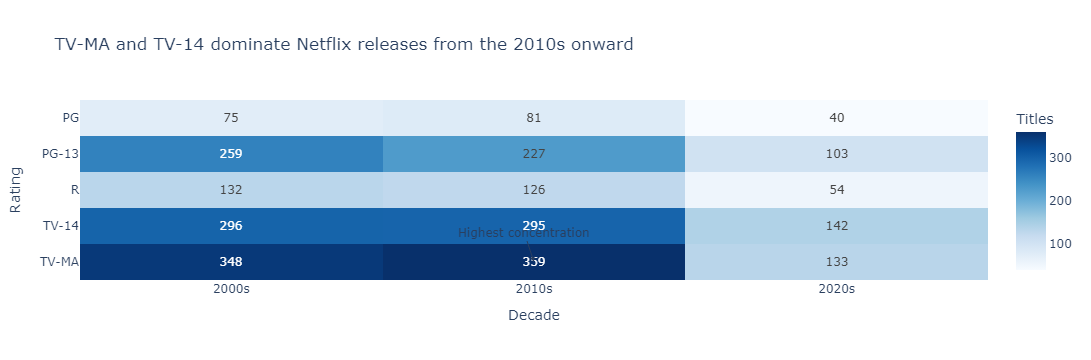

In [18]:
# Task 1

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Filter ratings
ratings_filter = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
heatmap_df = df[df['rating'].isin(ratings_filter)]

# Group data
heatmap_data = (
    heatmap_df
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

# Plot heatmap
fig = px.imshow(
    heatmap_pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto',
    labels=dict(x='Decade', y='Rating', color='Titles'),
    title='TV-MA and TV-14 dominate Netflix releases from the 2010s onward'
)

# Annotate a key cell
fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Highest concentration',
    showarrow=True,
    arrowhead=2
)

fig.show()

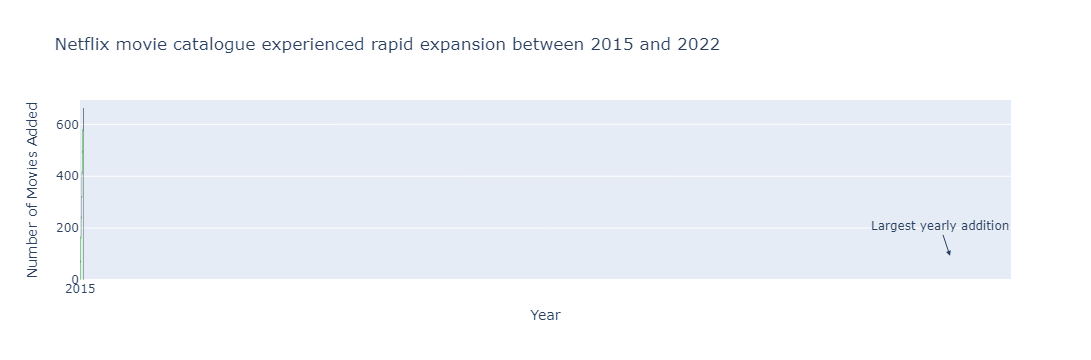

In [20]:
# Task 2

# Filter Movies only
movies_df = df[df['type'] == 'Movie'].copy()

# Group by added year
waterfall_df = (
    movies_df
    .groupby('added_year')
    .size()
    .reset_index(name='titles')
)

# Filter years 2015-2022
waterfall_df = waterfall_df[
    waterfall_df['added_year'].between(2015, 2022)
]

# Find largest addition year
max_row = waterfall_df.loc[waterfall_df['titles'].idxmax()]

# Create waterfall chart
fig = go.Figure(go.Waterfall(
    name='Movie Additions',
    orientation='v',
    measure=['relative'] * len(waterfall_df) + ['total'],
    x=list(waterfall_df['added_year'].astype(str)) + ['Total'],
    y=list(waterfall_df['titles']) + [0],
    connector={"line": {"color": "gray"}},
    increasing={"marker": {"color": "green"}},
    decreasing={"marker": {"color": "red"}},
    totals={"marker": {"color": "blue"}}
))

# Add annotation
fig.add_annotation(
    x=str(max_row['added_year']),
    y=max_row['titles'],
    text='Largest yearly addition',
    showarrow=True,
    arrowhead=2
)

# Layout
fig.update_layout(
    title='Netflix movie catalogue experienced rapid expansion between 2015 and 2022',
    xaxis_title='Year',
    yaxis_title='Number of Movies Added'
)

fig.show()